<a href="https://colab.research.google.com/github/harshana-cs/Ai-Ml/blob/main/Tutorial_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Auto-Encoder
Self Supervisior techinque
actual value ==input



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


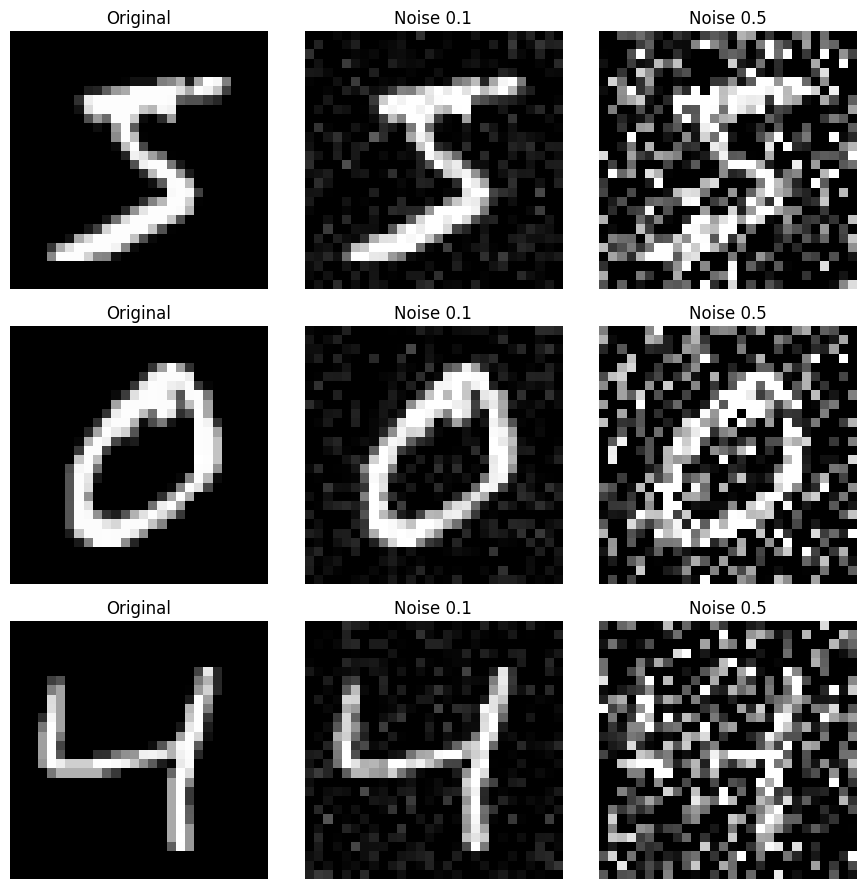

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))
#Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)
#Visualize in a 3 x 3 grid
n = 3 # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
# Original image
  ax = plt.subplot(n, 3, i * 3 + 1)
  plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
  plt.title("Original")
  plt.axis("off")
  # Low noise image
  ax = plt.subplot(n, 3, i * 3 + 2)
  plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap="gray")
  plt.title("Noise 0.1")
  plt.axis("off")
# High noise image
  ax = plt.subplot(n, 3, i * 3 + 3)
  plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap="gray")
  plt.title("Noise 0.5")
  plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
def build_encoder(input_shape=(28, 28, 1)):
  """
  Builds the encoder part of the convolutional autoencoder.
  Parameters:
  input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
  Returns:
  input_img (Keras Input): Input layer of the model.
  encoded (Keras Tensor): Encoded representation after convolution and pooling.
  """
  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
  x = MaxPooling2D((2, 2), padding="same")(x)
  x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
  encoded = MaxPooling2D((2, 2), padding="same", name="encoded")(x)
  return input_img, encoded

In [ ]:
def build_decoder(encoded_input):
  x = Conv2D(64, (3, 3), activation="relu", padding="same")(encoded_input)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoded")(x)
  return decoded

In [ ]:
def build_autoencoder():
  """
  Constructs and compiles the full convolutional autoencoder by connecting encoder and
  decoder.
  Returns:
  autoencoder (Keras Model): Compiled autoencoder model.
  """
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss="binary_crossentropy")
  return autoencoder

In [ ]:

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()
# Train with noisy input and clean target
history = autoencoder.fit(
x_train_noisy_high, x_train,
epochs=10,
batch_size=128,
shuffle=True,
validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1539 - val_loss: 0.1133
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1095 - val_loss: 0.1055
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1038 - val_loss: 0.1010
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1011 - val_loss: 0.0993
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0995 - val_loss: 0.0983
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0985 - val_loss: 0.0972
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0977 - val_loss: 0.0973
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0970 - val_loss: 0.0961
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0964 - val_loss: 0.0958
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0959 - val_loss: 0.0951


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


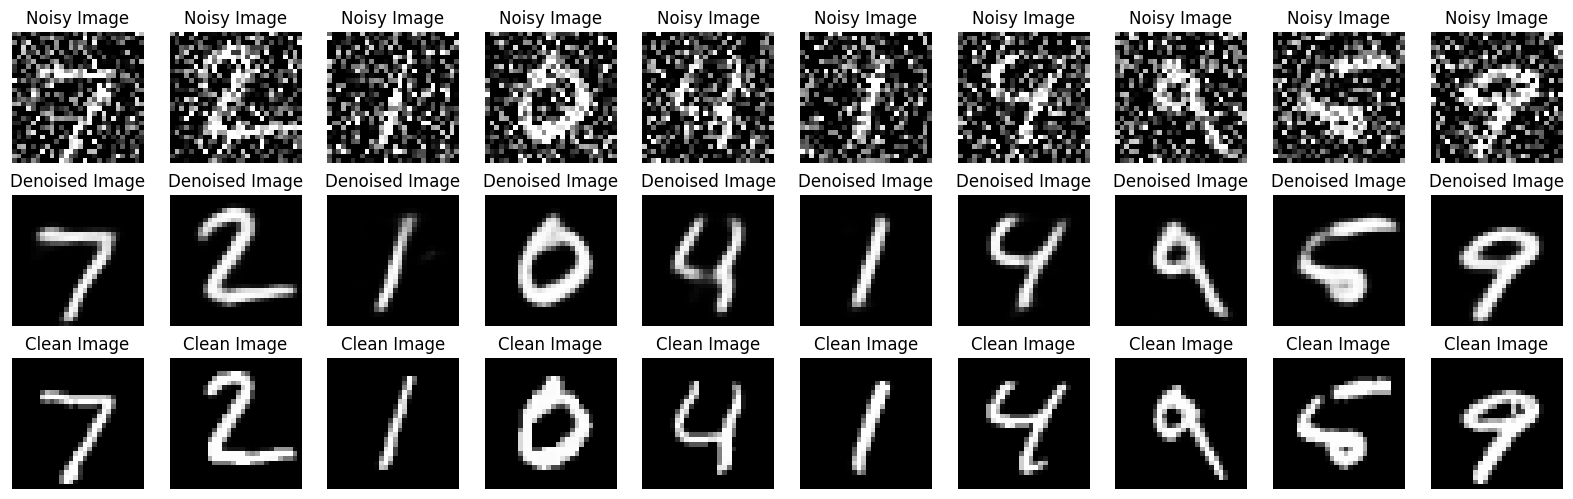

In [ ]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)
# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
  plt.figure(figsize=(20, 6))
  for i in range(n):
    # Plot noisy images
    plt.subplot(3, n, i + 1)
    plt.imshow(noisy_images[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy Image")
    plt.axis("off")
    # Plot denoised images
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised Image")
    plt.axis("off")
    # Plot clean images
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(clean_images[i].reshape(28, 28), cmap="gray")
    plt.title("Clean Image")
    plt.axis("off")
  plt.show()
# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

# DataSet Devanagari Handwritten Digit Dataset

In [ ]:
import os
import numpy as np
from PIL import Image, UnidentifiedImageError
import random

# Define dataset paths
train_dir = "/content/drive/MyDrive/AIML2026/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AIML2026/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load all images and labels
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))  # Sorted for consistent label mapping
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            try:
                img = Image.open(image_path).convert("L")  # Convert to grayscale
                img = img.resize((img_width, img_height))  # Resize to 28x28
                img_array = np.array(img) / 255.0  # Normalize to [0,1]
                img_array = np.expand_dims(img_array, axis=-1)  # Add channel dimension

                images.append(img_array)
                labels.append(label)
            except UnidentifiedImageError:
                print(f"Warning: Could not identify image file: {image_path}. Skipping.")
            except Exception as e:
                print(f"Error processing image {image_path}: {e}. Skipping.")

    return np.array(images), np.array(labels)


# Load training and testing datasets
x_train1, y_train1 = load_images_from_folder(train_dir)
x_test1, y_test1 = load_images_from_folder(test_dir)


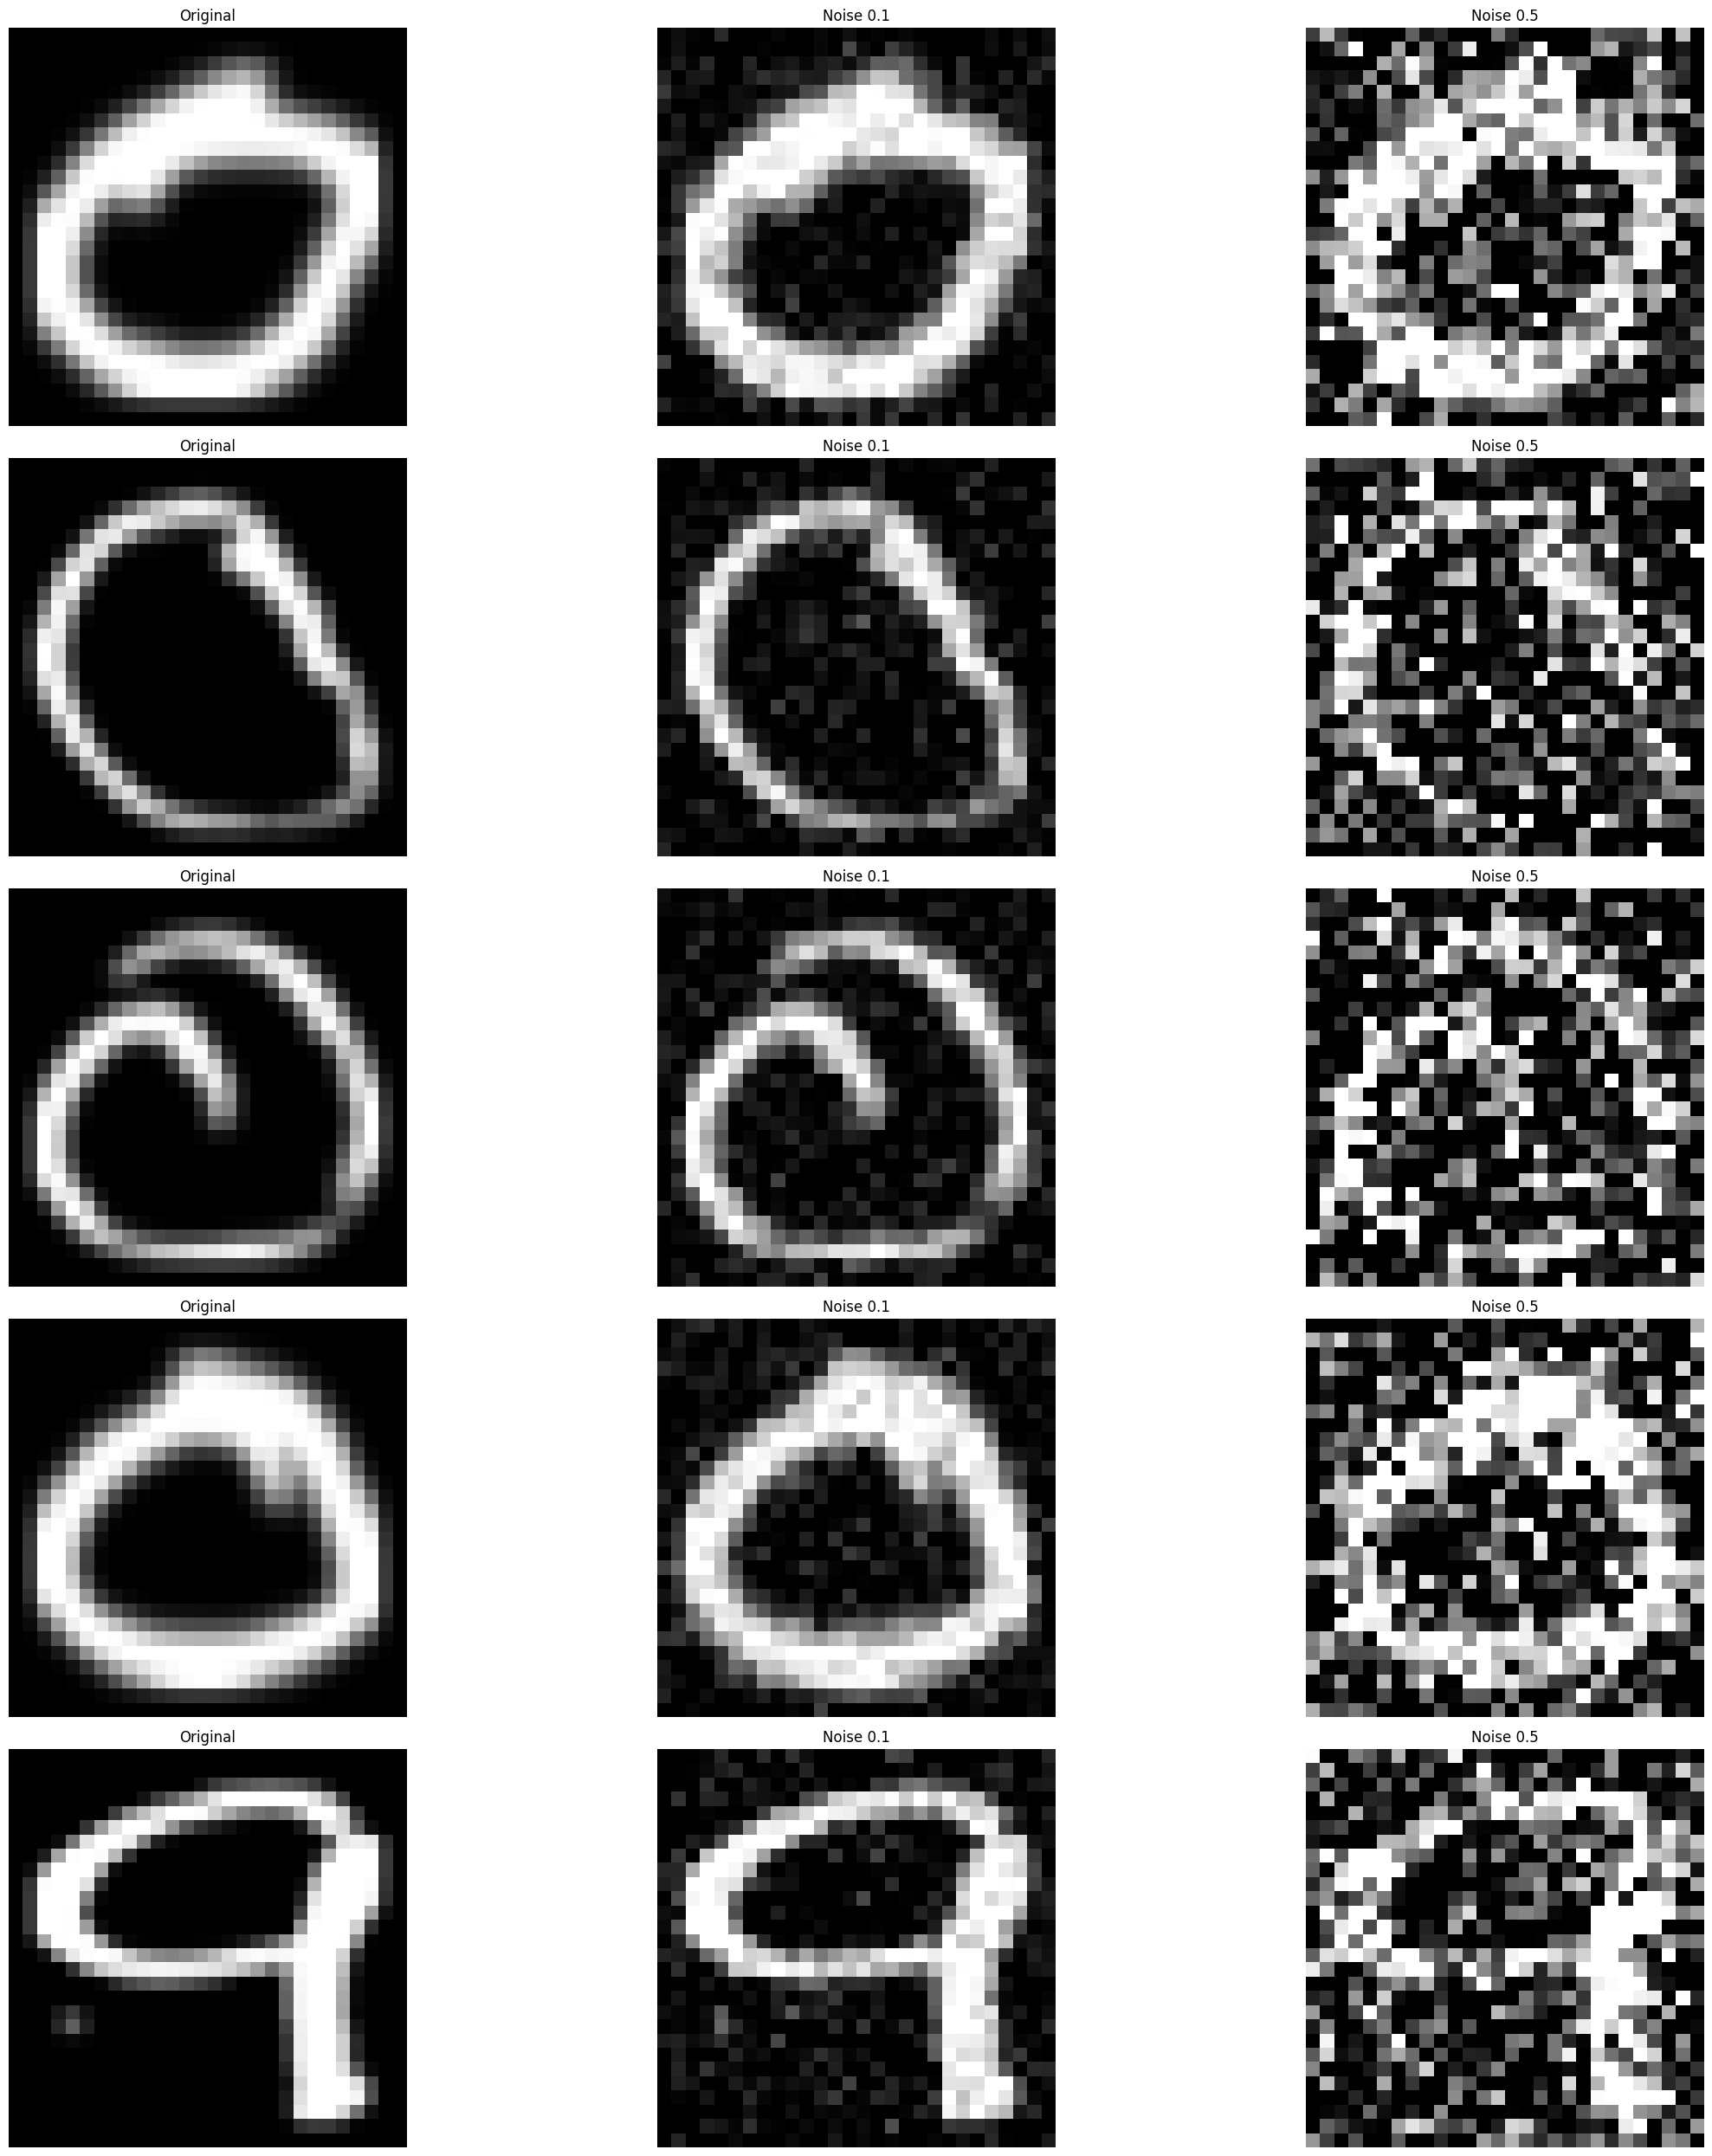

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5
x_train_noisy_low1 = x_train1 + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train1.shape)
x_train_noisy_high1 = x_train1 + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train1.shape)
x_test_noisy_low1 = x_test1 + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test1.shape)
x_test_noisy_high1 = x_test1 + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test1.shape)

# Clip pixel values to [0, 1]
x_train_noisy_low1 = np.clip(x_train_noisy_low1, 0., 1.)

x_test_noisy_low1 = np.clip(x_test_noisy_low1, 0., 1.)
x_train_noisy_high1 = np.clip(x_train_noisy_high1, 0., 1.)
x_test_noisy_high1 = np.clip(x_test_noisy_high1, 0., 1.)

#Visualize in a 3 x 3 grid
s = 500
n = 5# number of images to show
plt.figure(figsize=(25, 25))
for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train1[i*s].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low1[i*s].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')
    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high1[i*s].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
history = autoencoder.fit(
    x_train_noisy_high1, x_train1,
    epochs = 10,
    batch_size = 128,
    shuffle = True,
    validation_data = (x_test_noisy_high1, x_test1)
)

Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.1841 - val_loss: 0.1801
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1799 - val_loss: 0.1789
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1787 - val_loss: 0.1780
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1780 - val_loss: 0.1775
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1772 - val_loss: 0.1769
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1767 - val_loss: 0.1763
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1765 - val_loss: 0.1762
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1759 - val_loss: 0.1759
Epoch 9/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1757 - val_loss: 0.1764
Epoch 10/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1753 - val_loss: 0.1756


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


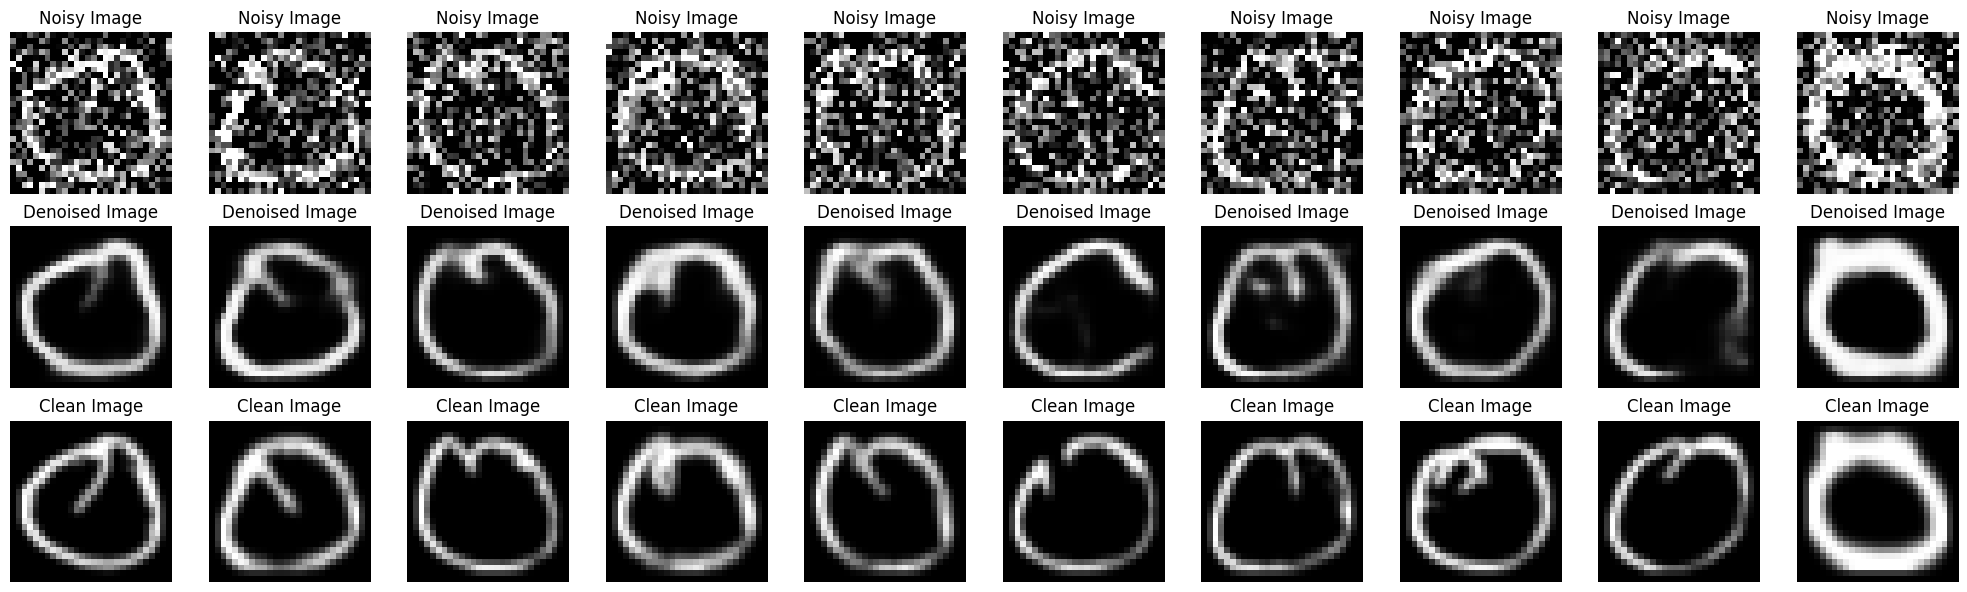

In [ ]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high1)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high1, denoised_images, x_test1, n=10)

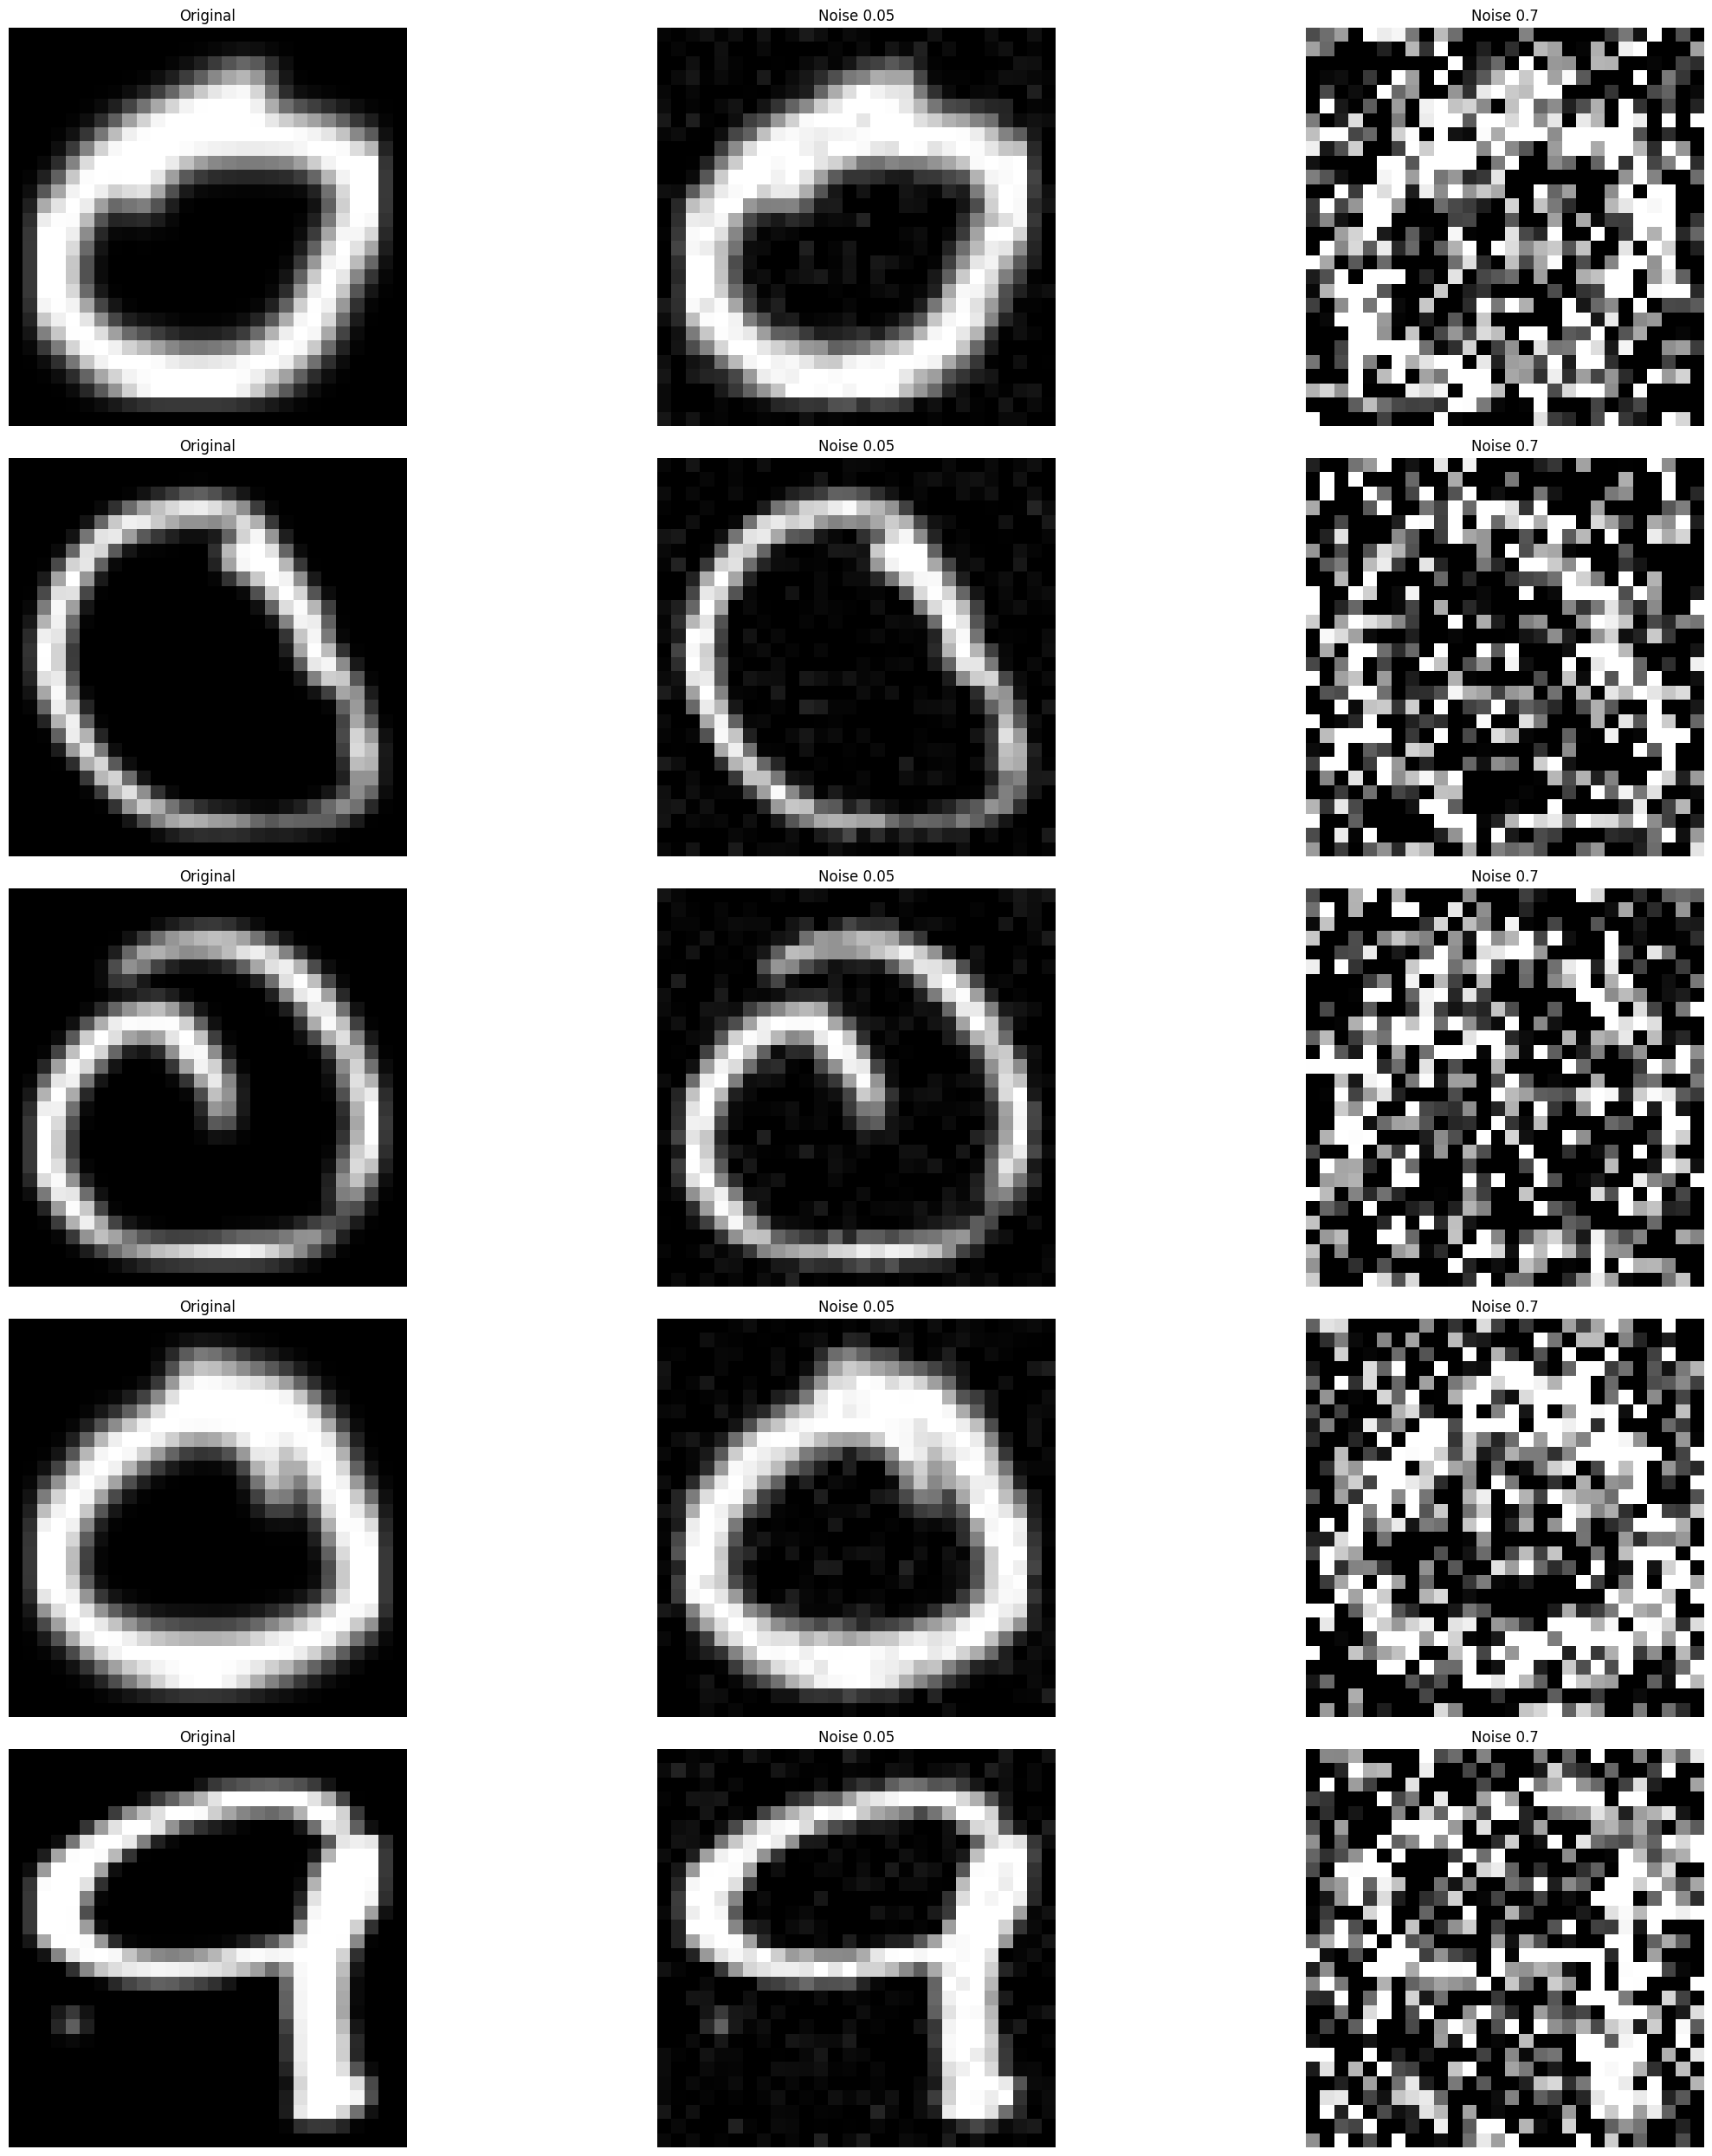

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Generate noisy versions
noise_factor_low = 0.05
noise_factor_high = 0.7
x_train_noisy_low1 = x_train1 + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train1.shape)
x_train_noisy_high1 = x_train1 + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train1.shape)
x_test_noisy_low1 = x_test1 + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test1.shape)
x_test_noisy_high1 = x_test1 + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test1.shape)

# Clip pixel values to [0, 1]
x_train_noisy_low1 = np.clip(x_train_noisy_low1, 0., 1.)

x_test_noisy_low1 = np.clip(x_test_noisy_low1, 0., 1.)
x_train_noisy_high1 = np.clip(x_train_noisy_high1, 0., 1.)
x_test_noisy_high1 = np.clip(x_test_noisy_high1, 0., 1.)

#Visualize in a 3 x 3 grid
s = 500
n = 5# number of images to show
plt.figure(figsize=(25, 25))
for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train1[i*s].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low1[i*s].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.05")
    plt.axis('off')
    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high1[i*s].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.7")
    plt.axis('off')
plt.tight_layout()
plt.show()